In [7]:
# Install kagglehub if not already installed
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# 1. Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

# 2. List files to find the exact CSV name
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 3. Load the dataset
df = pd.read_csv(full_path)

# 4. The first twenty rows of dataset
print("\nFirst 20 rows of the Titanic Dataset:")
print(df.head(20))

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset

First 20 rows of the Titanic Dataset:
    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   
12           13         0       3   
13           14         0       3   
14           15         0       3   
15           16         1       2   
16           17         0       3   
17           18         1       2   
18           19         0       3   
19           20         1       3   

                                                 Name     Se

In [8]:
# Keeping only the required features
data = df[['Fare', 'Survived']]


In [9]:
# Pre-processing: Dropping rows with missing values
print(f"Dataset before pre-processed. Total records: {len(data)}")
data = data.dropna()


Dataset before pre-processed. Total records: 891


In [10]:
# Reshaping data for Sklearn (X must be 2D)
X = data[['Fare']].values
y = data['Survived'].values

print(f"Dataset pre-processed. Total records: {len(data)}")

Dataset pre-processed. Total records: 891


In [11]:
from sklearn.model_selection import train_test_split

# Splitting 75% for training, 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 668 rows
Testing set: 223 rows


In [17]:
from sklearn.linear_model import LinearRegression

# Initialize the Simple Linear Regression model
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

# Output the coefficients
print(f"Model Intercept: {model.intercept_:.4f}")
print(f"Model Slope (Coefficient): {model.coef_[0]:.4f}")
print(f"Y = {model.intercept_:.4f} + ({model.coef_[0]:.4f})X")

Model Intercept: 0.3023
Model Slope (Coefficient): 0.0024
Y = 0.3023 + (0.0024)X


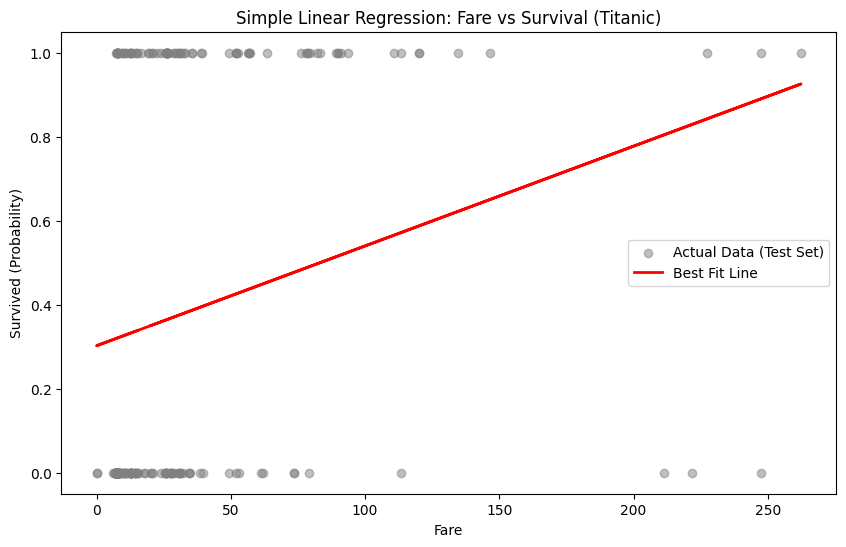

In [19]:
import matplotlib.pyplot as plt

# Create predictions for the regression line
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))

# Plotting the actual test data points
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual Data (Test Set)')

# Plotting the best fit line
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Best Fit Line')

plt.title('Simple Linear Regression: Fare vs Survival (Titanic)')
plt.xlabel('Fare')
plt.ylabel('Survived (Probability)')
plt.legend()
plt.show()

In [22]:
# conclusion:
# The plot shows a positive correlation between Fare and Survival i.e., the passengers who paid more had a statistically
# higher likelihood of being among the survivors then those who paid less.